In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Jupyter runs this from this folder; the figures go to results/figures/.
os.makedirs('results/figures', exist_ok=True)
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150,
})

# Bright pairs (light + saturated). Yellow for grounded, fuchsia for erroneous.
YELLOW_PRE,   YELLOW_POST   = "#fff1a8", "#f5b800"   # pale yellow → vivid amber
FUCHSIA_PRE,  FUCHSIA_POST  = "#fcc6df", "#e91e63"   # pale pink   → vivid fuchsia

GROUP_PRE  = {'mainstream': YELLOW_PRE,   'skeptical': FUCHSIA_PRE}
GROUP_POST = {'mainstream': YELLOW_POST,  'skeptical': FUCHSIA_POST}
GROUP_TITLE = {'mainstream': 'Grounded judges (true prior)',
               'skeptical':  'Erroneous judges (false prior)'}
CLAUDE_PRE_COLOR  = '#7b1fa2'   # deep purple — contrasts cleanly with yellow/fuchsia
CLAUDE_POST_COLOR = '#4a148c'
PANEL_BG = '#fafafa'

# Brighter per-model palette for supp_cap_delta
MODEL_COLOR  = {'Qwen2.5-7B':'#1e88e5', 'Llama-3.1-8B':'#e91e63',
                'Gemma-3-4B':'#00c853', 'Claude':'#7b1fa2'}
MODEL_LABELS = {'Qwen2.5-7B':'Qwen2.5-7B', 'Llama-3.1-8B':'Llama-3.1-8B',
                'Gemma-3-4B':'Gemma-3-4B', 'Claude':'Claude Sonnet 4'}
MODELS_OPEN  = ['Qwen2.5-7B', 'Llama-3.1-8B', 'Gemma-3-4B']
MODELS_ALL   = ['Qwen2.5-7B', 'Llama-3.1-8B', 'Gemma-3-4B', 'Claude']

def style_panel(ax, group_label=None):
    """Panel chrome: grey bg, % ticks, soft y grid, label box."""
    ax.set_facecolor(PANEL_BG)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    if group_label:
        # Label box at lower-right so it never overlaps Δ-pp annotations on tall bars.
        ax.text(0.99, 0.95, group_label, transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#aaa', alpha=0.9))

def annotate_bars(ax, values, xs, color, bold=False):
    for v, xi in zip(values, xs):
        if not np.isfinite(v):
            continue
        ax.text(xi, v + 1.2, f"{v:.0f}%", ha='center', va='bottom',
                fontsize=7.5, color=color,
                fontweight=('bold' if bold else 'normal'))

def annotate_delta(ax, pre_vals, post_vals, xs, offset=6):
    """Reference-style Δ pp callout above each model pair (post − pre).
    Positioned dynamically just above the taller bar of each pair."""
    for pre, post, xi in zip(pre_vals, post_vals, xs):
        if not (np.isfinite(pre) and np.isfinite(post)):
            continue
        delta = post - pre
        y = max(pre, post) + offset
        ax.text(xi, y, f"Δ={delta:+.1f} pp",
                ha='center', va='bottom', fontsize=7.5,
                color='#333', style='italic')

def save(name):
    for ext in ['pdf','png']:
        plt.savefig(f'results/figures/{name}.{ext}', bbox_inches='tight', dpi=150)
    plt.show(); print(f'→ results/figures/{name}.pdf')


In [2]:
import os, numpy as np, pandas as pd
from load_results import load_evaluations

raw = {
    'Qwen2.5-7B':   load_evaluations('Qwen2.5-7B-Instruct'),
    'Llama-3.1-8B': load_evaluations('Llama-3.1-8B-Instruct'),
    'Gemma-3-4B':   load_evaluations('gemma-3-4b-it'),
}
for df in raw.values():
    df['pre_correct']  = df['pre_statement_ground_truth_alignment'].astype(int)
    df['post_correct'] = df['post_statement_ground_truth_alignment'].astype(int)

# Claude Sonnet 4 reference: per-claim C3 (GPB system prompt) evaluations from the
# collaborators' temperature-0 run -- the run behind the paper's Sec. 5.2 numbers.
CLAUDE_DIR = '../debate_experiment_one_judge_con_persona/results/sonnet_temp_0'
_parts = []
for group, dtype, order in [('mainstream', 'normal',   'original'),
                            ('skeptical',  'normal',   'original'),
                            ('mainstream', 'inverted', 'inverted'),
                            ('skeptical',  'inverted', 'inverted')]:
    df = pd.read_csv(os.path.join(CLAUDE_DIR, f'evaluations_{group}_{order}_sonnet_temp_0.csv'))
    df['group'], df['debate_type'], df['condition'] = group, dtype, 'C3'
    df['pre_correct']  = df['pre_statement_ground_truth_alignment'].astype(int)
    df['post_correct'] = df['post_statement_ground_truth_alignment'].astype(int)
    _parts.append(df)
claude = pd.concat(_parts, ignore_index=True)

def acc(df, group, cond, dtype, col):
    s = df[(df.group == group) & (df.condition == cond) & (df.debate_type == dtype)]
    return s[col].mean() * 100 if len(s) else np.nan

print('Loaded from results/:')
for name, df in raw.items():
    print(f'  {name:14s}  {len(df):5d} rows · groups={sorted(df.group.unique())} · '
          f'conds={sorted(df.condition.unique())} · types={sorted(df.debate_type.unique())}')
print(f'  Claude          {len(claude):5d} rows from {CLAUDE_DIR} (C3, normal+inverted)')


Loaded from results/:
  Qwen2.5-7B       2340 rows · groups=['mainstream', 'skeptical'] · conds=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'] · types=['inverted', 'normal']
  Llama-3.1-8B     2340 rows · groups=['mainstream', 'skeptical'] · conds=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'] · types=['inverted', 'normal']
  Gemma-3-4B       2340 rows · groups=['mainstream', 'skeptical'] · conds=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'] · types=['inverted', 'normal']
  Claude            396 rows from ../debate_experiment_one_judge_con_persona/results/sonnet_temp_0 (C3, normal+inverted)


---
## Figure 1 — Prompting shifts pre-debate priors (place after experimental design table)

Pre-debate accuracy only, across C1 / C3 / C5. Validates the prompting-based method.

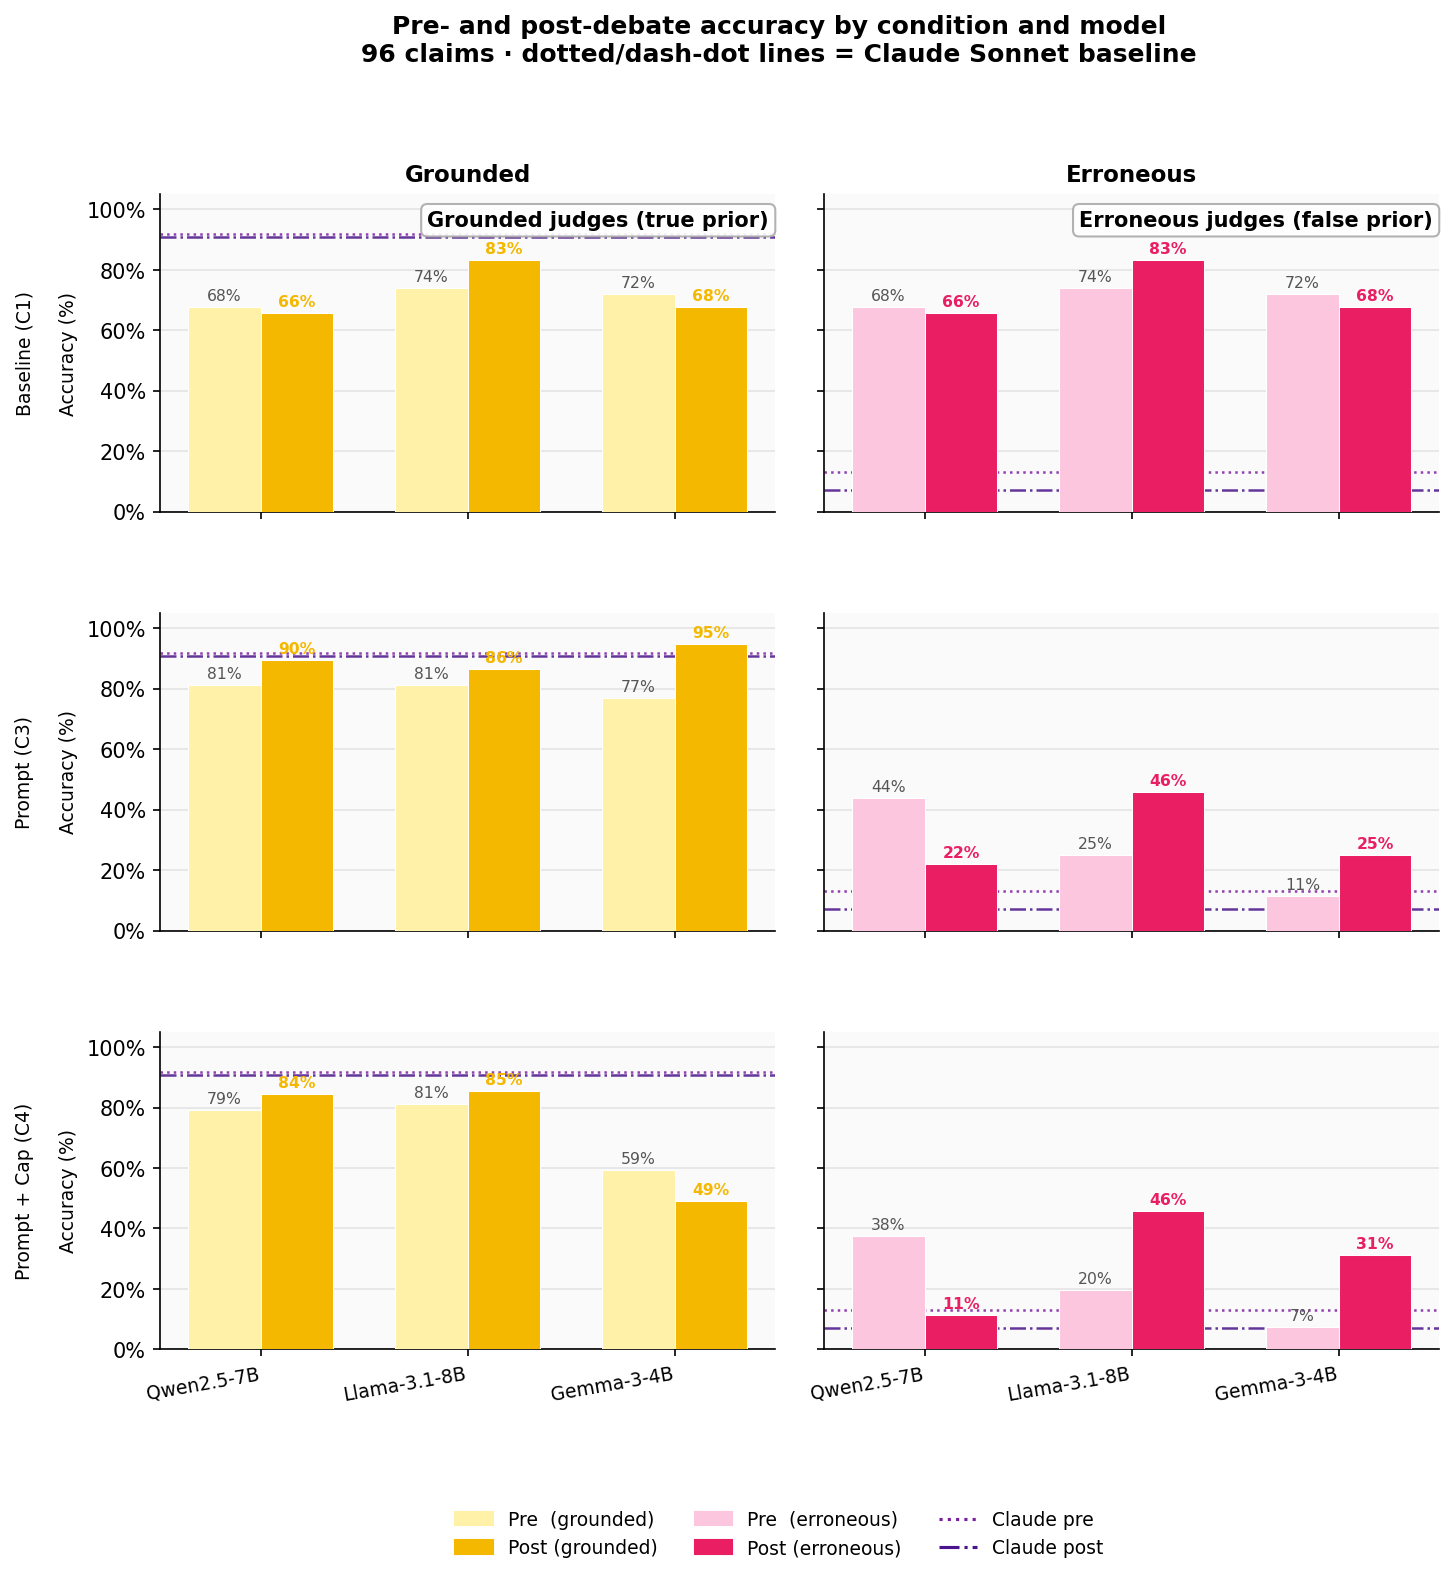

→ results/figures/fig_main.pdf


In [3]:
# Fig 1: pre/post accuracy across C1, C3, C4 — per-model, both groups
rows = [('C1','Baseline (C1)'), ('C3','Prompt (C3)'), ('C4','Prompt + Cap (C4)')]
x, w = np.arange(len(MODELS_OPEN)), 0.35

fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharey=True, sharex=True)
fig.subplots_adjust(hspace=0.32, wspace=0.08)

for row_i, (cond, row_label) in enumerate(rows):
    for col_i, group in enumerate(['mainstream', 'skeptical']):
        ax = axes[row_i][col_i]
        pre_color, post_color = GROUP_PRE[group], GROUP_POST[group]

        pre_vals  = [acc(raw[m], group, cond, 'normal', 'pre_correct')  for m in MODELS_OPEN]
        post_vals = [acc(raw[m], group, cond, 'normal', 'post_correct') for m in MODELS_OPEN]

        ax.bar(x - w/2, pre_vals,  w, color=pre_color,  zorder=3, edgecolor='white', linewidth=0.5)
        ax.bar(x + w/2, post_vals, w, color=post_color, zorder=3, edgecolor='white', linewidth=0.5)
        annotate_bars(ax, pre_vals,  x - w/2, color='#555')
        annotate_bars(ax, post_vals, x + w/2, color=post_color, bold=True)

        cl_pre  = acc(claude, group, 'C3', 'normal', 'pre_correct')
        cl_post = acc(claude, group, 'C3', 'normal', 'post_correct')
        ax.axhline(cl_pre,  color=CLAUDE_PRE_COLOR,  lw=1.2, ls=':',  alpha=0.85,
                   label=f'Claude pre ({cl_pre:.0f}%)')
        ax.axhline(cl_post, color=CLAUDE_POST_COLOR, lw=1.2, ls='-.', alpha=0.85,
                   label=f'Claude post ({cl_post:.0f}%)')

        ax.set_ylim(0, 105)
        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS_OPEN],
                           rotation=10, ha='right', fontsize=9)
        style_panel(ax, group_label=GROUP_TITLE[group] if row_i == 0 else None)

        if row_i == 0:
            ax.set_title(['Grounded', 'Erroneous'][col_i], fontweight='bold', fontsize=11)
        if col_i == 0:
            ax.set_ylabel(f'{row_label}\n\nAccuracy (%)', fontsize=9)

fig.suptitle('Pre- and post-debate accuracy by condition and model\n'
             '96 claims · dotted/dash-dot lines = Claude Sonnet baseline',
             fontweight='bold', fontsize=12, y=1.00)

handles = [
    mpatches.Patch(color=YELLOW_PRE,   label='Pre  (grounded)'),
    mpatches.Patch(color=YELLOW_POST,  label='Post (grounded)'),
    mpatches.Patch(color=FUCHSIA_PRE,  label='Pre  (erroneous)'),
    mpatches.Patch(color=FUCHSIA_POST, label='Post (erroneous)'),
    plt.Line2D([0],[0], color=CLAUDE_PRE_COLOR,  ls=':',  lw=1.5, label='Claude pre'),
    plt.Line2D([0],[0], color=CLAUDE_POST_COLOR, ls='-.', lw=1.5, label='Claude post'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=9, frameon=False)
save('fig_main')


---
## Figure 2 — Capping further shifts priors (place immediately after Figure 1)

Within each condition pair, solid = no cap, hatched = with cap. Shows the mechanistic intervention adds a further shift on top of the prompt.

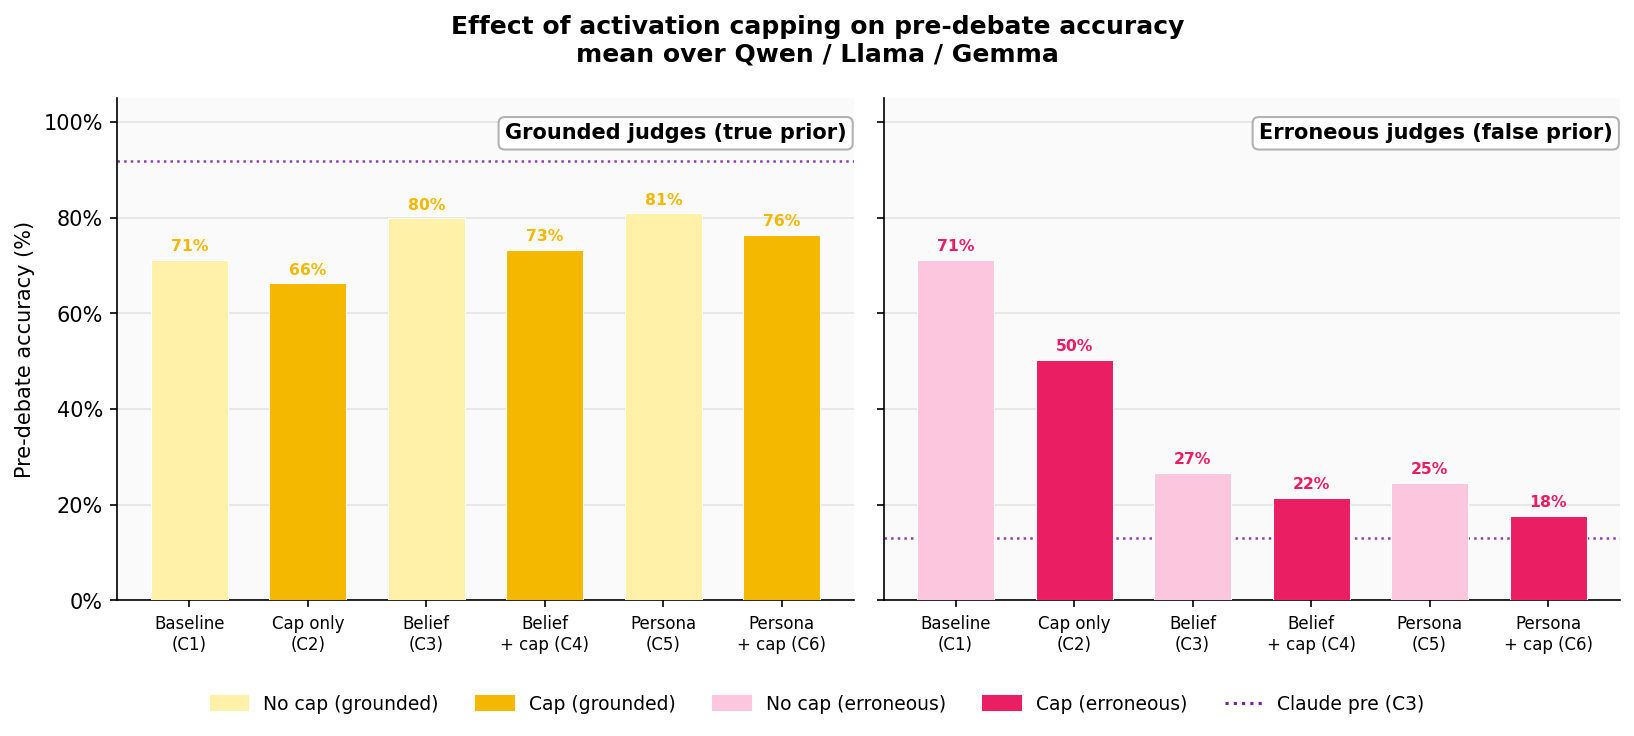

→ results/figures/fig2_cap_prior.pdf


In [4]:
# Fig 2: pre-debate accuracy, all 6 conditions (cap-on solid, cap-off light)
conds  = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
labels = ['Baseline\n(C1)', 'Cap only\n(C2)', 'Belief\n(C3)',
          'Belief\n+ cap (C4)', 'Persona\n(C5)', 'Persona\n+ cap (C6)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    pre_color, post_color = GROUP_PRE[group], GROUP_POST[group]
    means = [np.mean([acc(raw[m], group, c, 'normal', 'pre_correct') for m in MODELS_OPEN])
             for c in conds]
    colors = [pre_color if i % 2 == 0 else post_color for i in range(6)]
    ax.bar(range(6), means, color=colors, width=0.65, zorder=3,
           edgecolor='white', linewidth=0.5)
    annotate_bars(ax, means, np.arange(6), color=post_color, bold=True)

    cl_pre = acc(claude, group, 'C3', 'normal', 'pre_correct')
    ax.axhline(cl_pre, color=CLAUDE_PRE_COLOR, lw=1.2, ls=':', alpha=0.85,
               label=f'Claude pre ({cl_pre:.0f}%)')

    ax.set_xticks(range(6)); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 105)
    style_panel(ax, group_label=GROUP_TITLE[group])

axes[0].set_ylabel('Pre-debate accuracy (%)')
fig.suptitle('Effect of activation capping on pre-debate accuracy\n'
             'mean over Qwen / Llama / Gemma',
             fontweight='bold', fontsize=12)

handles = [
    mpatches.Patch(color=YELLOW_PRE,   label='No cap (grounded)'),
    mpatches.Patch(color=YELLOW_POST,  label='Cap (grounded)'),
    mpatches.Patch(color=FUCHSIA_PRE,  label='No cap (erroneous)'),
    mpatches.Patch(color=FUCHSIA_POST, label='Cap (erroneous)'),
    plt.Line2D([0],[0], color=CLAUDE_PRE_COLOR, ls=':', lw=1.5, label='Claude pre (C3)'),
]
fig.legend(handles=handles, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=False)
plt.tight_layout()
save('fig2_cap_prior')


---
## Figure 3 — Debates shift beliefs in both directions (place at start of Results)

C3 condition, normal debates. Pre (light) vs post (dark) accuracy for all models and Claude.

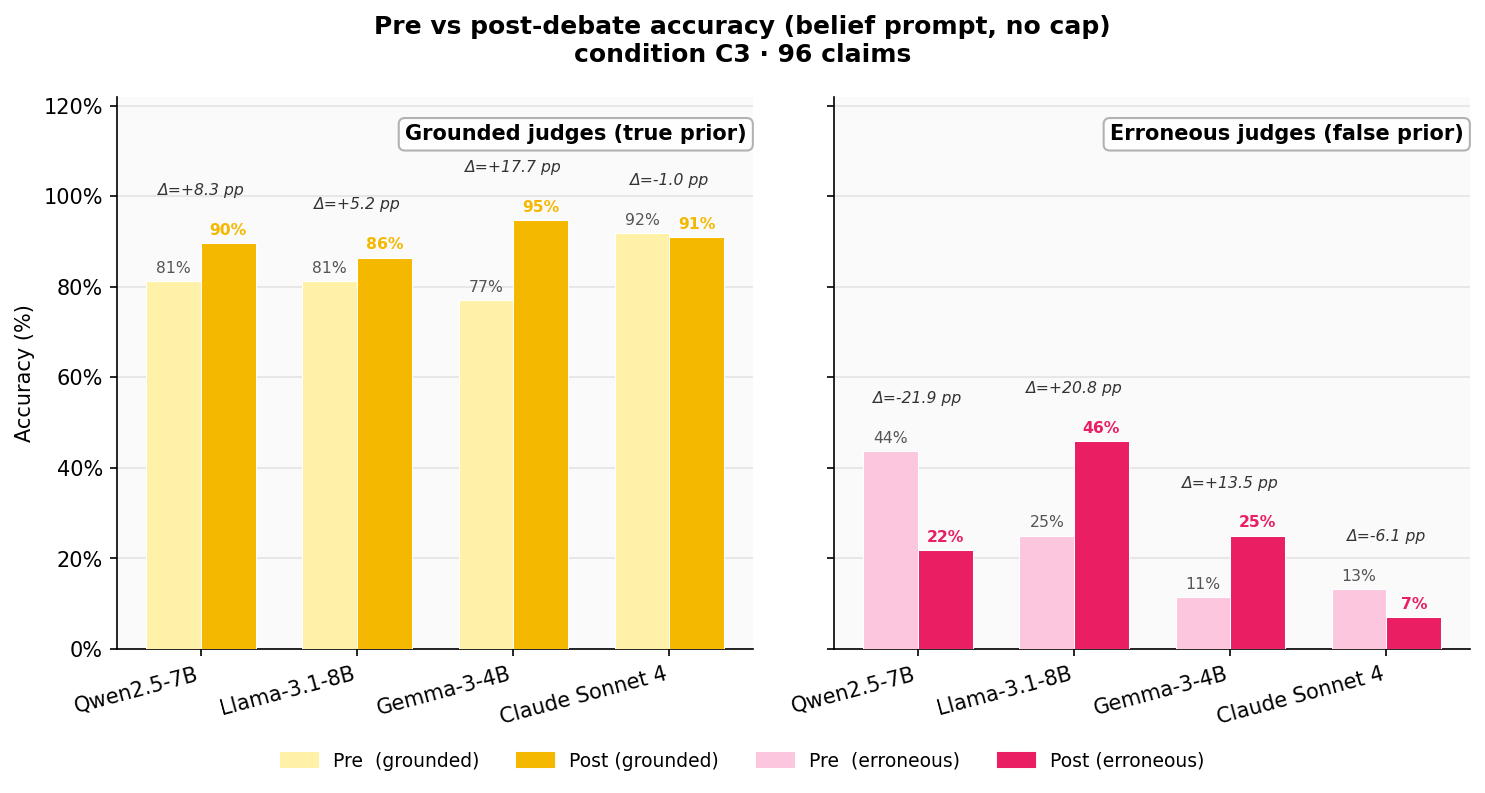

→ results/figures/fig3_pre_post_c3.pdf


In [5]:
all_data = {**raw, 'Claude': claude}

# Fig 3: pre vs post debate accuracy, C3, all models
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
x = np.arange(len(MODELS_ALL))
w = 0.35

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    pre_color, post_color = GROUP_PRE[group], GROUP_POST[group]
    pre  = [acc(all_data[m], group, 'C3', 'normal', 'pre_correct')  for m in MODELS_ALL]
    post = [acc(all_data[m], group, 'C3', 'normal', 'post_correct') for m in MODELS_ALL]

    ax.bar(x - w/2, pre,  w, color=pre_color,  zorder=3, edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, post, w, color=post_color, zorder=3, edgecolor='white', linewidth=0.5)
    annotate_bars(ax, pre,  x - w/2, color='#555')
    annotate_bars(ax, post, x + w/2, color=post_color, bold=True)
    annotate_delta(ax, pre, post, x, offset=10)

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS_ALL], rotation=15, ha='right')
    ax.set_ylim(0, 122)
    style_panel(ax, group_label=GROUP_TITLE[group])

axes[0].set_ylabel('Accuracy (%)')
fig.suptitle('Pre vs post-debate accuracy (belief prompt, no cap)\n'
             'condition C3 · 96 claims',
             fontweight='bold', fontsize=12)

handles = [
    mpatches.Patch(color=YELLOW_PRE,   label='Pre  (grounded)'),
    mpatches.Patch(color=YELLOW_POST,  label='Post (grounded)'),
    mpatches.Patch(color=FUCHSIA_PRE,  label='Pre  (erroneous)'),
    mpatches.Patch(color=FUCHSIA_POST, label='Post (erroneous)'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=False)
plt.tight_layout()
save('fig3_pre_post_c3')


---
## Supplementary: inversion effect and cap delta (not in main text)

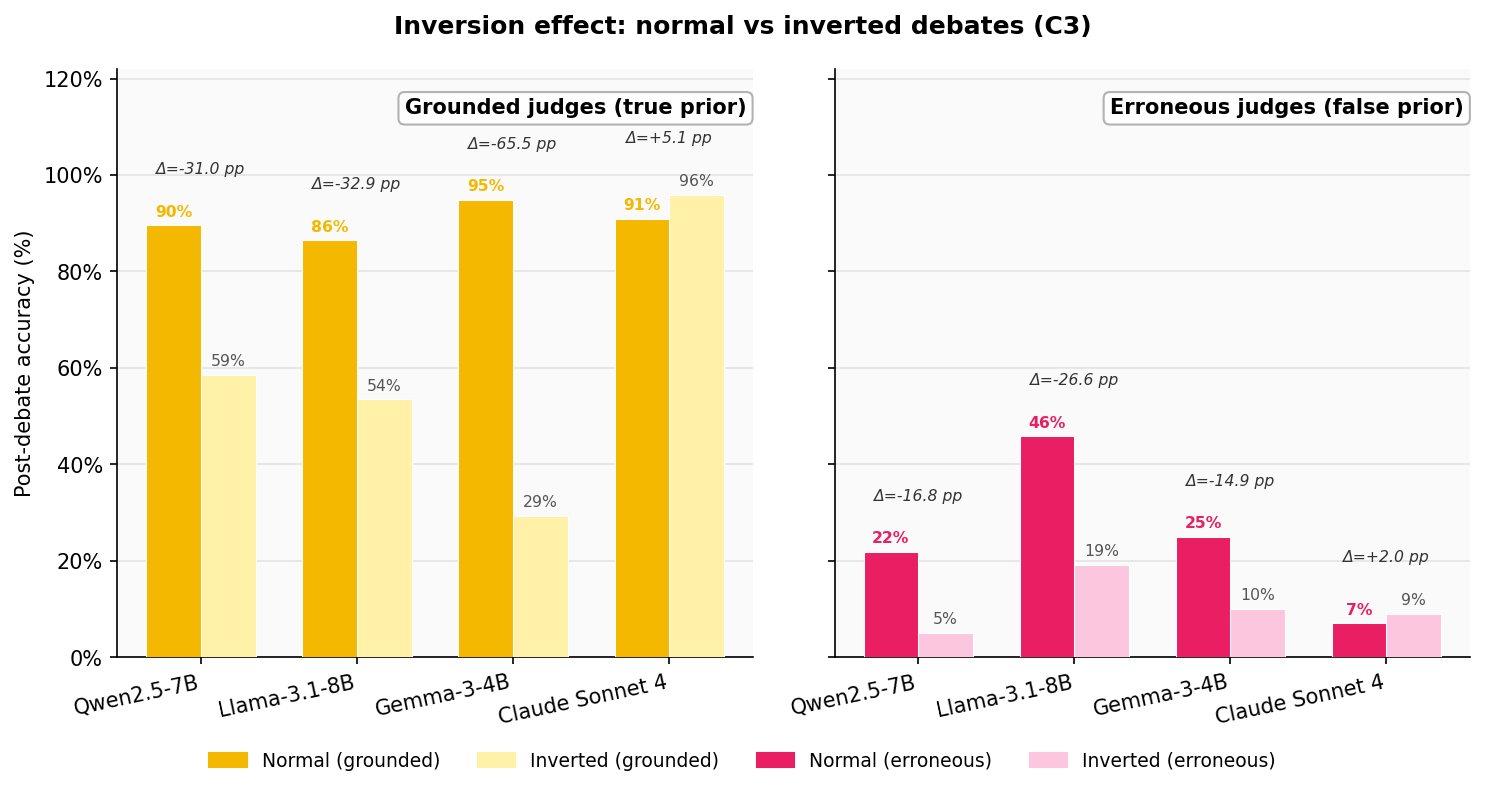

→ results/figures/supp_inversion.pdf


In [6]:
# Inversion effect: normal vs inverted post-debate, C3
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
x = np.arange(len(MODELS_ALL)); w = 0.35

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    pre_color, post_color = GROUP_PRE[group], GROUP_POST[group]
    n_vals = [acc(all_data[m], group, 'C3', 'normal',   'post_correct') for m in MODELS_ALL]
    i_vals = [acc(all_data[m], group, 'C3', 'inverted', 'post_correct') for m in MODELS_ALL]

    ax.bar(x - w/2, n_vals, w, color=post_color, zorder=3, edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, i_vals, w, color=pre_color,  zorder=3, edgecolor='white', linewidth=0.5)
    annotate_bars(ax, n_vals, x - w/2, color=post_color, bold=True)
    annotate_bars(ax, i_vals, x + w/2, color='#555')
    annotate_delta(ax, n_vals, i_vals, x, offset=10)

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS_ALL], rotation=12, ha='right')
    ax.set_ylim(0, 122)
    style_panel(ax, group_label=GROUP_TITLE[group])

axes[0].set_ylabel('Post-debate accuracy (%)')
fig.suptitle('Inversion effect: normal vs inverted debates (C3)',
             fontweight='bold', fontsize=12)

handles = [
    mpatches.Patch(color=YELLOW_POST,  label='Normal (grounded)'),
    mpatches.Patch(color=YELLOW_PRE,   label='Inverted (grounded)'),
    mpatches.Patch(color=FUCHSIA_POST, label='Normal (erroneous)'),
    mpatches.Patch(color=FUCHSIA_PRE,  label='Inverted (erroneous)'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=False)
plt.tight_layout()
save('supp_inversion')


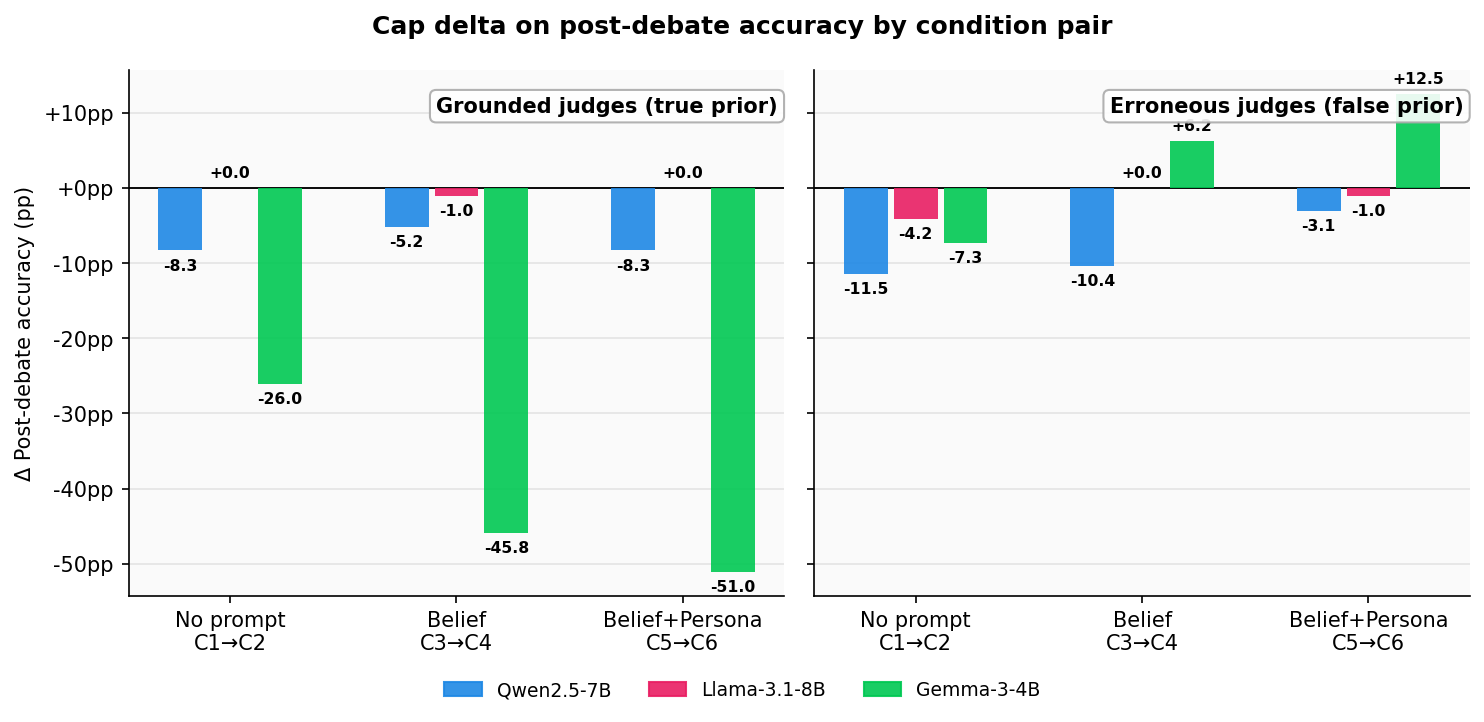

→ results/figures/supp_cap_delta.pdf


In [7]:
PAIRS = [('C1','C2','No prompt\nC1→C2'),
         ('C3','C4','Belief\nC3→C4'),
         ('C5','C6','Belief+Persona\nC5→C6')]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
x = np.arange(len(PAIRS)); w = 0.22

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    post_color = GROUP_POST[group]
    for m_i, model in enumerate(MODELS_OPEN):
        deltas = [acc(raw[model],group,p[1],'normal','post_correct')
                  - acc(raw[model],group,p[0],'normal','post_correct') for p in PAIRS]
        offset = (m_i - 1) * w
        bars = ax.bar(x + offset, deltas, w*0.88,
                      color=MODEL_COLOR[model], alpha=0.9, zorder=3, linewidth=0)
        for bar, val in zip(bars, deltas):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2,
                        val + (1.0 if val>=0 else -1.0),
                        f'{val:+.1f}',
                        ha='center', va='bottom' if val>=0 else 'top',
                        fontsize=7.5, fontweight='bold')
    ax.axhline(0, color='black', lw=0.9, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([p[2] for p in PAIRS])
    style_panel(ax, group_label=GROUP_TITLE[group])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

axes[0].set_ylabel('Δ Post-debate accuracy (pp)')
fig.suptitle('Cap delta on post-debate accuracy by condition pair',
             fontweight='bold', fontsize=12)

handles = [mpatches.Patch(color=MODEL_COLOR[m], alpha=0.9, label=MODEL_LABELS[m])
           for m in MODELS_OPEN]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.06), fontsize=9, frameon=False)
plt.tight_layout()
save('supp_cap_delta')

In [8]:
print('C3, normal — pre → post')
for group in ['mainstream','skeptical']:
    print(f'  {group.upper()}')
    for m in MODELS_ALL:
        pre  = acc(all_data[m], group, 'C3', 'normal', 'pre_correct')
        post = acc(all_data[m], group, 'C3', 'normal', 'post_correct')
        print(f'    {MODEL_LABELS[m]:18s}  {pre:.1f}% → {post:.1f}%  ({post-pre:+.1f}pp)')

C3, normal — pre → post
  MAINSTREAM
    Qwen2.5-7B          81.2% → 89.6%  (+8.3pp)
    Llama-3.1-8B        81.2% → 86.5%  (+5.2pp)
    Gemma-3-4B          77.1% → 94.8%  (+17.7pp)
    Claude Sonnet 4     91.9% → 90.9%  (-1.0pp)
  SKEPTICAL
    Qwen2.5-7B          43.8% → 21.9%  (-21.9pp)
    Llama-3.1-8B        25.0% → 45.8%  (+20.8pp)
    Gemma-3-4B          11.5% → 25.0%  (+13.5pp)
    Claude Sonnet 4     13.1% → 7.1%  (-6.1pp)
